<a href="https://colab.research.google.com/github/aryashivakumar/dataScience/blob/main/Unit6/Unit6Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Unit 6 Project: Modeling Housing Prices with a Generalized Linear Model**

# **Part I: Introduction**

For my Unit 6 Project I will analyze the factors that determine housing prices using a GLM using multiple predictors. Housing prices are central in economics becuase they reflect interest rates, investment, neighborhood quality, and access to goods nearby such as education and safety

Understanding the relationship between these variables and housing prices is important for a variety of factors:
This includes policy makers, homebuyers, and allocation of resources.

Data: https://www.kaggle.com/datasets/ericpierce/austinhousingprices?resource=download



In [3]:
import graphviz as gv


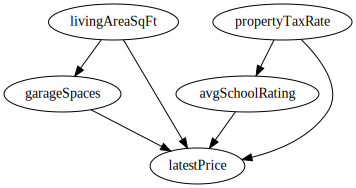

In [2]:
import graphviz as gv

h_dag = gv.Digraph(name="Housing Price DAG")

# Nodes = main drivers of house price
h_dag.node('L','livingAreaSqFt')
h_dag.node('S','avgSchoolRating')
h_dag.node('G','garageSpaces')
h_dag.node('T','propertyTaxRate')
h_dag.node('P','latestPrice')

# Direct effects on price
h_dag.edges([
    ('L','P'), # bigger house → higher price
    ('S','P'), # better schools → higher price
    ('G','P'), # more garages → higher price
    ('T','P')  # higher taxes → can lower price, but also fund schools (indirect effect)
])

# Causal relationships between features
h_dag.edge('L','G') # bigger houses → more garage spaces
h_dag.edge('T','S') # higher taxes → better schools

h_dag

# **Part II: Data**

Data source:

This data is a housing dataset compiled from kaggle:

In [ ]:
import pandas as pd
import numpy as np
!pip install bambi

import bambi as bmb
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
housing = pd.read_csv(
    "https://raw.githubusercontent.com/aryashivakumar/dataScience/refs/heads/main/Unit6/austinHousingData%20-%20austinHousingData.csv"
)

housing.head()


,city,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasCooling,...,numOfElementarySchools,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories
0,pflugerville,14424 Lake Victor Dr,78660,"14424 Lake Victor Dr, Pflugerville, TX 78660 i...",30.430632,-97.663078,1.98,2,True,True,...,0,1,1,1.266667,2.666667,1063,14,3.0,4,2
1,pflugerville,1104 Strickling Dr,78660,Absolutely GORGEOUS 4 Bedroom home with 2 full...,30.432672,-97.661697,1.98,2,True,True,...,0,1,1,1.400000,2.666667,1063,14,2.0,4,1
2,pflugerville,1408 Fort Dessau Rd,78660,Under construction - estimated completion in A...,30.409748,-97.639771,1.98,0,True,True,...,2,1,1,1.200000,3.000000,1108,14,2.0,3,1
3,pflugerville,1025 Strickling Dr,78660,Absolutely darling one story home in charming ...,30.432112,-97.661659,1.98,2,True,True,...,0,1,1,1.400000,2.666667,1063,14,2.0,3,1
4,pflugerville,15005 Donna Jane Loop,78660,Brimming with appeal & warm livability! Sleek ...,30.437368,-97.656860,1.98,0,True,True,...,0,1,1,1.133333,4.000000,1223,14,3.0,3,2


In [7]:
cols = [
    "latestPrice",
    "livingAreaSqFt",
    "avgSchoolRating",
    "propertyTaxRate",
    "garageSpaces"
]

housing = housing[cols].dropna()

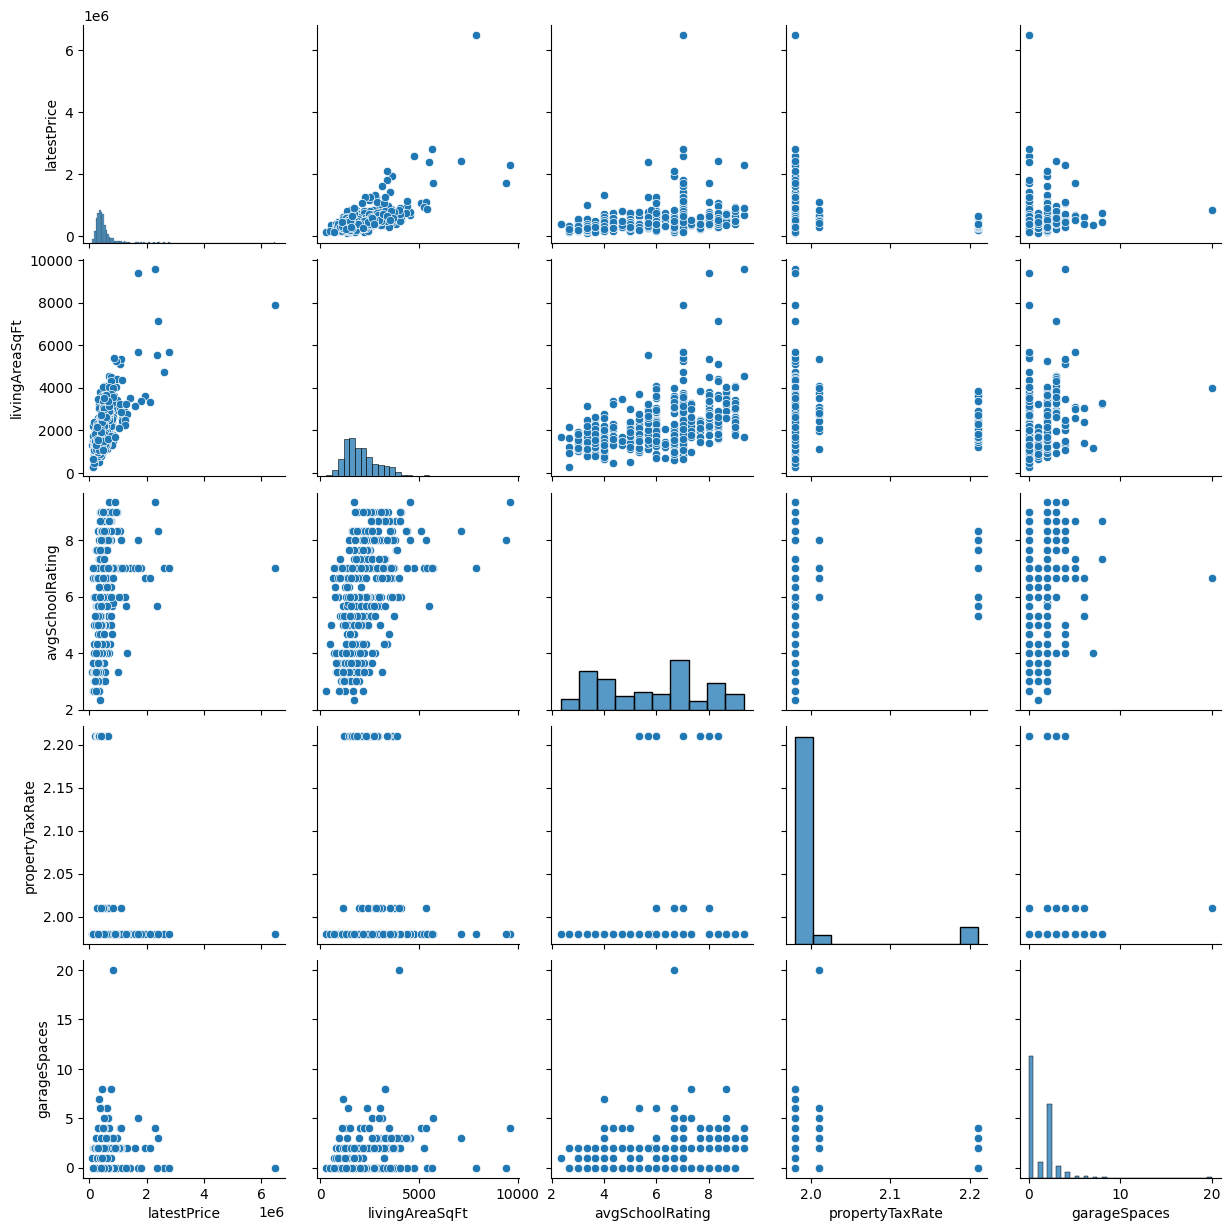

In [8]:
sns.pairplot(housing[cols].sample(500))


In [9]:
housing = housing.copy()

# log transform for skewed price and size
housing["logPrice"] = np.log(housing["latestPrice"])
housing["logSqFt"] = np.log(housing["livingAreaSqFt"])

# treat school rating as categorical
housing["avgSchoolRating"] = housing["avgSchoolRating"].astype("category")


made a copy of the dataset to avoid changing the original data

taking the log of price and square footage reduces skew, stabilizes variance, and allows us to model proportional (percentage) changes

In [ ]:
model_1 = bmb.Model(
    "logPrice ~ logSqFt + avgSchoolRating + garageSpaces + propertyTaxRate",
    data=housing
)
idata_1 = model_1.fit(idata_kwargs={"log_likelihood": True})


In [ ]:
model_2 = bmb.Model(
    "logPrice ~ logSqFt * avgSchoolRating + garageSpaces + propertyTaxRate",
    data=housing
)

idata_2 = model_2.fit(idata_kwargs={"log_likelihood": True})


(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='logSqFt', ylabel='logPrice'>], dtype=object))

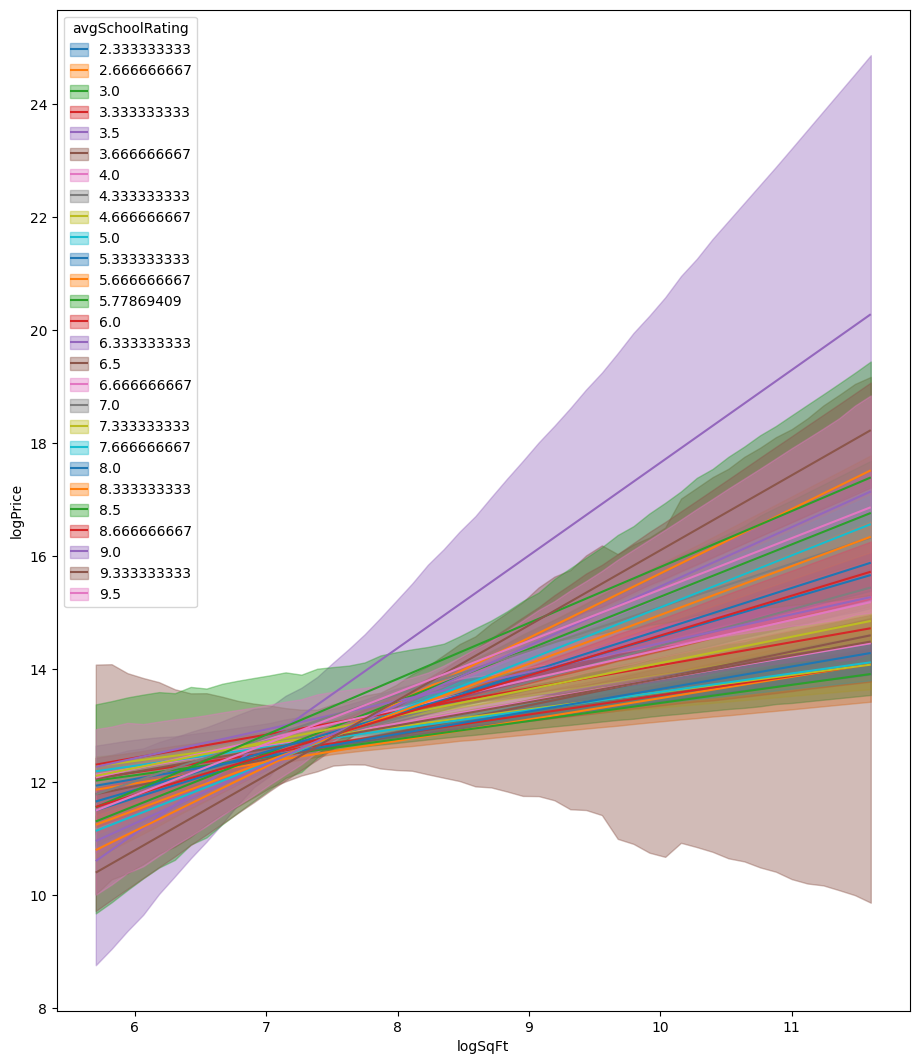

In [12]:
bmb.interpret.plot_predictions(
    model_2,
    idata_2,
    ["logSqFt", "avgSchoolRating"],
    fig_kwargs={"figsize": (11, 13)}
)

In [ ]:
model_3 = bmb.Model(
    "logPrice ~ logSqFt * garageSpaces + avgSchoolRating + propertyTaxRate",
    data=housing
)
idata_3 = model_3.fit(idata_kwargs={"log_likelihood": True})


(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='logSqFt', ylabel='logPrice'>], dtype=object))

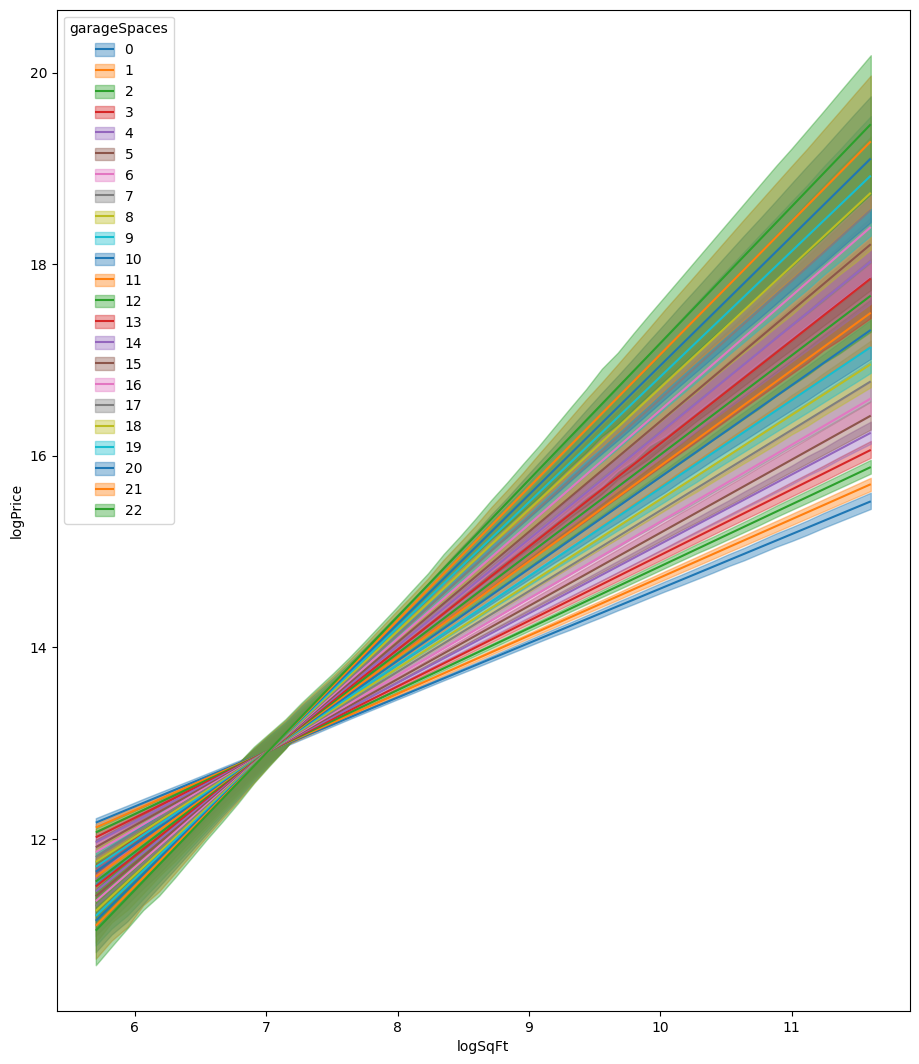

In [14]:
bmb.interpret.plot_predictions(
    model_3,
    idata_3,
    ["logSqFt", "garageSpaces"],
    fig_kwargs={"figsize": (11, 13)}
)

In [ ]:
model_4 = bmb.Model(
    "logPrice ~ avgSchoolRating * propertyTaxRate + logSqFt + garageSpaces",
    data=housing
)
idata_4 = model_4.fit(idata_kwargs={"log_likelihood": True})


This compares whether large homes benefit from highers rated schools compared to smaller homes

basically does extra square feet really matter more in good school districts vs bad ones

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

<Figure size 1200x800 with 0 Axes>

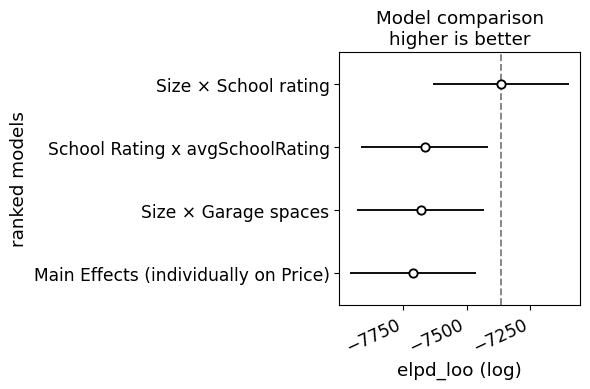

In [16]:
cmp = az.compare({
    "Main Effects (individually on Price)": idata_1,
    "Size × School rating": idata_2,
    "Size × Garage spaces": idata_3,
    "School Rating x avgSchoolRating": idata_4,
})

plt.figure(figsize=(12, 8))
az.plot_compare(cmp)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


Why Model 2 performed best:

Model 2 includes an interaction between logSqFt × avgSchoolRating.

It tests whether the impact of square footage on price changes depending on school quality.

This reflects real-world behavior: larger homes tend to be worth even more in better school districts.

The baseline model (Model 1) only includes main effects (logSqFt, avgSchoolRating, garageSpaces, propertyTaxRate).

It looks at how each variable affects price on its own.

It does not test whether variables influence each other.

It acts as a starting point to compare whether adding interactions improves the model.

Models 3 and 4 test other interactions (size × garage and school × tax).

In this dataset, those relationships were weaker, so they did not improve predictive performance as much as Model 2.

Conclusion:

House size and school quality together are the strongest drivers of housing prices in this data.

Utlized gemini in order to clean up some parts of code